In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# for visuallization
import plotly.express as px
# import kaleido # comment out for reproducing purposes
import scipy
from mpl_toolkits.mplot3d import Axes3D
from yellowbrick.cluster import KElbowVisualizer
# from kneed import KneeLocator

# %notebook matplotlib
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
df=pd.read_csv('data/3711.csv');df

,matchDate,symbol,matchPri,matchQty,tolMatchQty,matchTime,bidPri1,bidPri2,bidPri3,bidPri4,...,askQty3,askQty4,askQty5,openPri,highPri,lowPri,refPri,upPri,dnPri,label
0,20221220,3711,94.6,216,216,90003845,94.6,94.5,94.4,94.3,...,8,13,58,94.6,94.6,94.6,95.8,105,86.3,2.0
1,20221220,3711,94.6,1,217,90003921,94.7,94.6,94.5,94.4,...,1,18,1,94.6,94.6,94.6,95.8,105,86.3,1.0
2,20221220,3711,94.7,1,218,90005353,94.7,94.6,94.5,94.4,...,1,18,1,94.6,94.7,94.6,95.8,105,86.3,2.0
3,20221220,3711,94.7,1,219,90005400,94.7,94.6,94.5,94.4,...,19,33,18,94.6,94.7,94.6,95.8,105,86.3,2.0
4,20221220,3711,94.7,15,234,90006605,94.6,94.5,94.4,94.3,...,19,33,24,94.6,94.7,94.6,95.8,105,86.3,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5596,20221220,3711,93.3,1,15240,132456151,93.3,93.2,93.1,93.0,...,28,16,32,94.6,95.2,93.3,95.8,105,86.3,1.0
5597,20221220,3711,93.5,1,15242,132456435,93.3,93.2,93.1,93.0,...,16,32,36,94.6,95.2,93.3,95.8,105,86.3,0.0
5598,20221220,3711,93.3,1,15243,132457241,93.3,93.2,93.1,93.0,...,16,32,36,94.6,95.2,93.3,95.8,105,86.3,1.0
5599,20221220,3711,93.5,2,15245,132458268,93.3,93.2,93.1,93.0,...,16,32,36,94.6,95.2,93.3,95.8,105,86.3,0.0


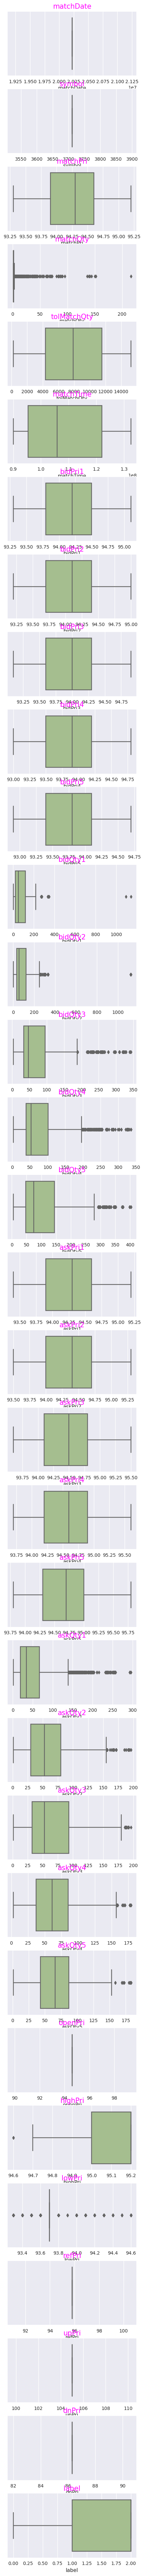

In [3]:
# --- [CELL 2]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
# === BEFORE (original) ===
# sns.set_style('darkgrid')
# fig, ax = plt.subplots(6, 1, figsize=(5, 20))#Original was 9,1
# 
# for i, col in enumerate(list(df.columns.values)):
#     axes_box  = ax[i]
#     sns.boxplot(data=df, x=col, ax=axes_box,color='#a5c687')
#     ax[i].set_title(col,fontsize=15,color='magenta')

# === AFTER (edited) ===
sns.set_style('darkgrid')
fig, ax = plt.subplots(len(df.columns), 1, figsize=(5, 3*len(df.columns)))

for i, col in enumerate(list(df.columns.values)):
    axes_box = ax[i]
    sns.boxplot(data=df, x=col, ax=axes_box, color='#a5c687')
    ax[i].set_title(col, fontsize=15, color='magenta')

In [4]:
import numpy as np

# Expect outputs from the plotting cell
assert "df" in globals(), "Expected df from previous cells"
assert "ax" in globals(), "Expected ax from previous plotting cell"

axes = np.ravel(ax)
assert axes.size > 0, "No subplot axes found"

# If plotting cell succeeded, it should only title as many subplots as available
expected_plotted = min(len(df.columns), axes.size)

titles = [a.get_title() for a in axes]
non_empty_titles = [t for t in titles if isinstance(t, str) and t.strip()]

# Exactly expected number of subplots should be populated
assert len(non_empty_titles) == expected_plotted, (
    f"Expected {expected_plotted} titled subplots, got {len(non_empty_titles)}"
)

# Titles should correspond to the first expected columns (loop order behavior)
expected_titles = list(df.columns[:expected_plotted])
assert non_empty_titles == expected_titles, (
    f"Unexpected subplot titles. Expected {expected_titles}, got {non_empty_titles}"
)

# Any remaining axes (if present) should be unused (no title)
for i in range(expected_plotted, axes.size):
    assert titles[i] == "", f"Axis {i} should be unused but has title {titles[i]!r}"

print(f"✓ Passed: plotted {expected_plotted} columns without exceeding subplot capacity")

✓ Passed: plotted 33 columns without exceeding subplot capacity
